In [22]:
#pip install lime

In [35]:
#LIME
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

df = pd.read_csv('/content/sample_data/Reviews.csv', encoding='latin-1')

print(df.shape)
print(df.columns)
df.head()

(568454, 10)
Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [24]:
df = df[['Text', 'Score']]

#Clean dataset
df = df.dropna()

#Convert rating
df['label'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

# X and Y
X = df['Text']
y = df['label']

#Train/Set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

#Model LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

#Result
y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))

#Lime Function
def predict_proba(texts):
    texts = list(texts)
    X = vectorizer.transform(texts)
    return model.predict_proba(X)

              precision    recall  f1-score   support

           0       0.81      0.66      0.72     24666
           1       0.91      0.96      0.93     89025

    accuracy                           0.89    113691
   macro avg       0.86      0.81      0.83    113691
weighted avg       0.89      0.89      0.89    113691



In [25]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=["negative", "positive"])

exp = explainer.explain_instance(
    X_test.iloc[0],
    predict_proba,
    num_features=10
)

exp.as_list()

[(np.str_('best'), 0.06849694481601086),
 (np.str_('satisfied'), 0.056448467333302554),
 (np.str_('free'), 0.044144906441959404),
 (np.str_('sooner'), 0.03629270887214161),
 (np.str_('brands'), 0.03449118811664241),
 (np.str_('Glutino'), -0.030374104549595334),
 (np.str_('isn'), -0.026424076082244424),
 (np.str_('gluten'), -0.025399200863761774),
 (np.str_('good'), 0.0220458247405568),
 (np.str_('makes'), 0.014007431435579875)]

In [26]:
# Visualize to Bar Chart
result = [
    ('best', 0.06880),
    ('satisfied', 0.05899),
    ('free', 0.04399),
    ('brands', 0.03734),
    ('sooner', 0.03723),
    ('Glutino', -0.02554),
    ('good',  0.02327),
    ('isn', -0.02307),
    ('texture', -0.01881),
    ('gluten', -0.01860),
]

#Seperate word and weight
words = [w for w, v in result]
values = [v for w, v in result]

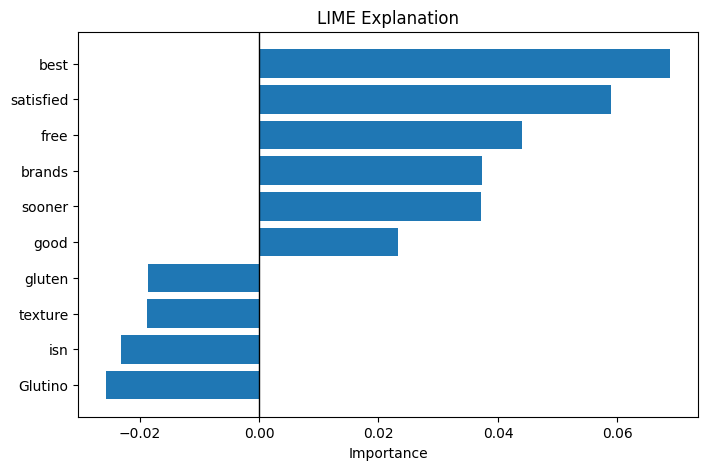

In [27]:
#using matplotlib
import numpy as np
import matplotlib.pyplot as plt

sorted_idx = np.argsort(values)

words = np.array(words)[sorted_idx]
values = np.array(values)[sorted_idx]

plt.figure(figsize=(8,5))
plt.barh(words, values)

plt.title("LIME Explanation")
plt.xlabel("Importance")
plt.axvline(0, color='black', linewidth=1)
plt.show()


<BarContainer object of 10 artists>

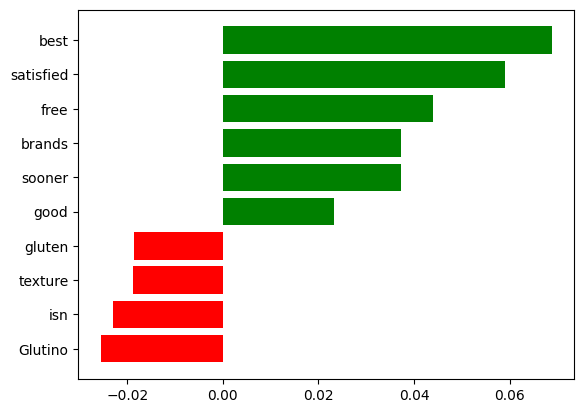

In [28]:
colors = ['green' if v > 0 else 'red' for v in values]

plt.barh(words, values, color=colors)

- Positive side:
best
satisfied
free
good
- Negative side:
gluten
Glutino
texture
isn

The bar chart visualizes word-level contributions from LIME. Positive values indicate words that support a positive sentiment prediction, while negative values indicate words that contribute to a negative sentiment prediction.

In [29]:
#pip install shap

In [30]:
# word mapping (feature-> name)
import pandas as pd
import numpy as np

feature_names = vectorizer.get_feature_names_out()

shap_values_array = shap_values.values

mean_shap = np.abs(shap_values_array).mean(axis=0)

df_shap = pd.DataFrame({
    "word": feature_names,
    "importance": mean_shap
})

df_shap = df_shap.sort_values("importance", ascending=False)

print(df_shap.head(10))

           word  importance
1966      great    0.331642
2605       love    0.247960
453        best    0.245439
1224  delicious    0.220652
1921       good    0.182406
3178    perfect    0.137988
2610      loves    0.132817
1551  excellent    0.101319
1641   favorite    0.097853
4457      taste    0.097507


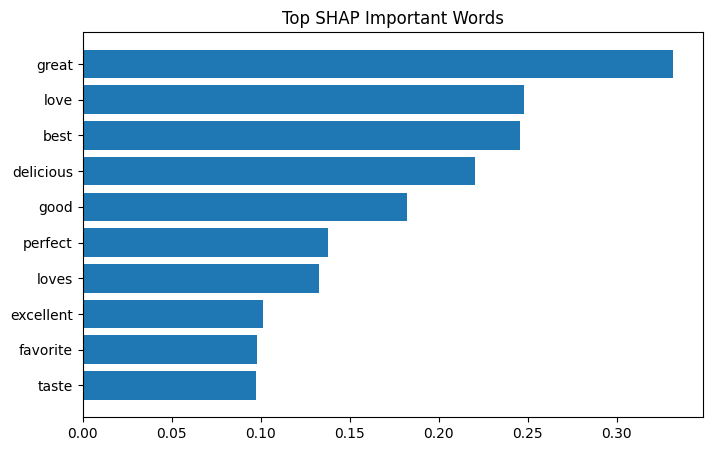

In [31]:
#Visualize SHAP using plot
import matplotlib.pyplot as plt

top = df_shap.head(10)

plt.figure(figsize=(8,5))
plt.barh(top["word"], top["importance"])
plt.gca().invert_yaxis()
plt.title("Top SHAP Important Words")
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


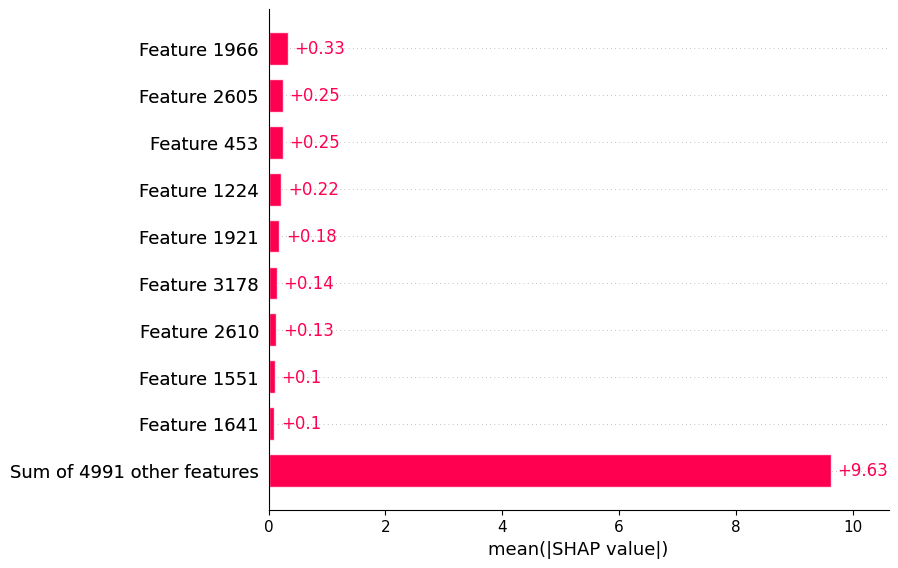

In [32]:
import shap
import numpy as np

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

explainer = shap.LinearExplainer(model, X_train_vec, feature_perturbation="interventional"
)

# important for performance
X_sample = X_test_vec[:200]

shap_values = explainer(X_sample)

#Bar plot
shap.plots.bar(shap_values)

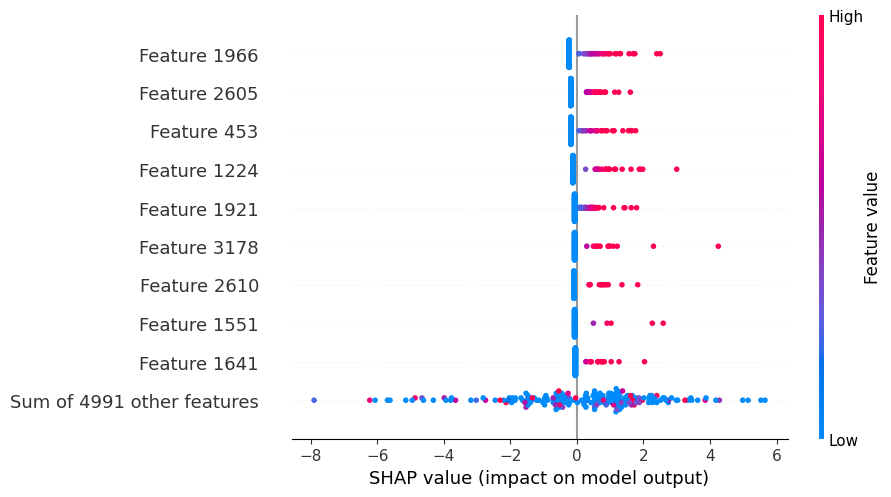

In [33]:

#SHAP beeswarm plot
shap.plots.beeswarm(shap_values)

- Bar plot
: which words matter most overall

- beeswarm plot
: distribution of word impact
positive vs negative influence


- Feature
: Review text (after conversion to TF-IDF)

- Feature meaning
: Feature = input of the model.

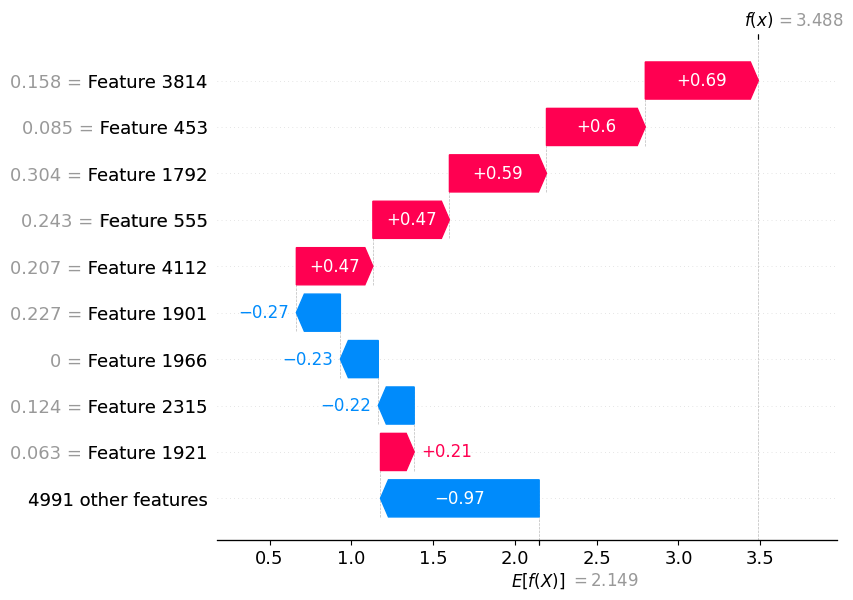

In [34]:
#Waterfall plot
shap.plots.waterfall(shap_values[0])

equivalent to LIME but more mathematically stable